# Analysing rain and cluster data

In [1]:
import fiona
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
from time import time
from tqdm import tqdm
import xarray as xr
import torch
import torch.nn as nn
import matplotlib.colors as colors
# from torch import optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

from climate_dataset import *

seed = 1234
np.random.seed(seed)

In [2]:
from climate_dataset import *
ppt_directory = "data/ppt-nc-1895-2020"
ppt_df, lat, lon = load_data(ppt_directory, dtype="ppt")

759it [00:06, 108.43it/s]


In [3]:
def show_states(west_coast=True, state_file="States/cb_2018_us_state_20m.shp"):
    shape = fiona.open(state_file)
    for s in shape:
        pts = s["geometry"]["coordinates"]
        for p in pts:
            state = np.array(p).squeeze()
            if state[:, 1].min() < 50 and state[:, 1].min() > 22:
                if not west_coast:
                    plt.plot(state[:, 0], state[:, 1], color="black")
                elif np.max(state[:, 0]) < -100:  # plot only west coast
                    plt.plot(state[:, 0], state[:, 1], color="black")

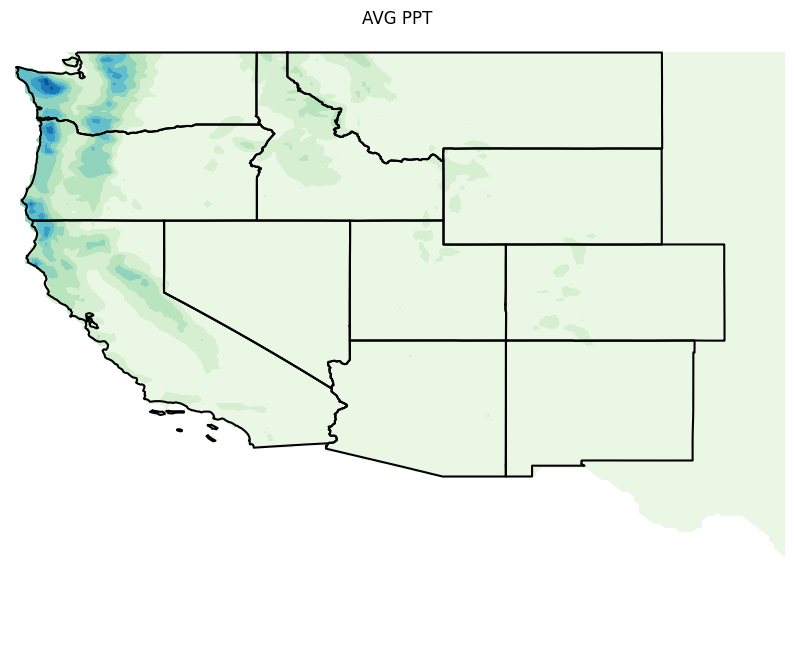

In [4]:
avg_ppt = ppt_df["ppt"].mean()

plt.figure(figsize=(10, 8))
xx, yy = np.meshgrid(lon, lat)
plt.contourf(xx, yy, avg_ppt, cmap="GnBu")
show_states()
plt.axis("off")
plt.title("AVG PPT")
plt.show()
plt.close()

In [5]:
def add_time(df):
    """Add Time Column"""
    min_year = np.min(df["Y"])
    df["T"] = (df["Y"] - min_year) * 12 + df["M"]
    return df


def add_season(df):
    """adds Season Column (0 for months 1,2,3 and 1 for months 10,11,12)"""
    df["season"] = ((df["M"] - 1) // 4).astype(bool).astype(int)
    return df


ppt_df = add_season(add_time(ppt_df))
ppt_df.to_csv("data/df.csv", index=False)


In [6]:
ppt_df.tail()

,F,Y,M,ppt,T,season
754,ppt_2020_11.nc,2020,11,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1511,1
755,ppt_2020_12.nc,2020,12,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1512,1
756,ppt_2021_01.nc,2021,1,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1513,0
757,ppt_2021_02.nc,2021,2,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1514,0
758,ppt_2021_03.nc,2021,3,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1515,0


Right now `ppt_df` contains information about the average precipitation in each longitudal/latitudal location for each year/month of interest.
Notice how the month column only contains months 1, 2, 3, 10, 11, and 12. These are the only months we are interested in since they are the periods of precipitation that we are trying to predict and are significant to agriculture.

## Load the clusters

These clusters are areas in the western US which have similar climates, determined with K-means clustering. There are 9 clusters total.

In [7]:
clusters = np.load("data/clusters.npy")
clusters.shape

(155, 150)

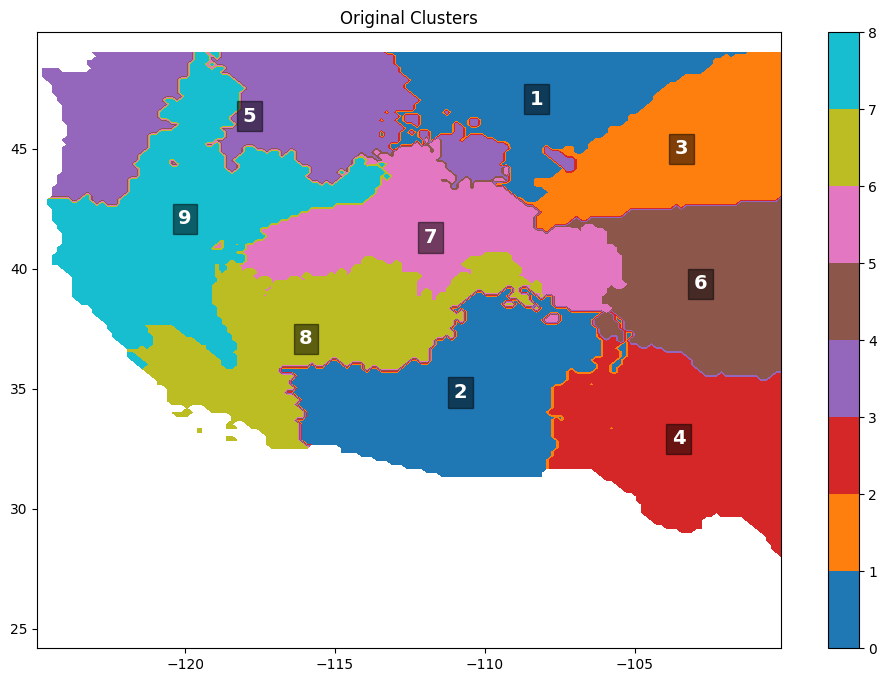

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Visualize the original cluster map
plt.figure(figsize=(12, 8))
xx, yy = np.meshgrid(lon, lat)
plt.contourf(xx, yy, clusters, levels=8, cmap="tab10")
plt.colorbar()
plt.title("Original Clusters")

# Step 2: Compute cluster centers
cluster_ids = np.unique(clusters)
for cluster_id in cluster_ids:
    cluster_mask = clusters == cluster_id  # Boolean mask for current cluster
    
    # Get the mean position of all points in the cluster
    if np.any(cluster_mask):  # Ensure the cluster exists
        center_lat = np.mean(yy[cluster_mask])
        center_lon = np.mean(xx[cluster_mask])

        # Step 3: Annotate the map with the cluster number
        plt.text(center_lon, center_lat, str(int(cluster_id+1)), 
                 color='white', fontsize=14, fontweight='bold', 
                 ha='center', va='center', bbox=dict(facecolor='black', alpha=0.5))


plt.show()


# Find the average precipitation for each cluster and add it to ppt_df


In [9]:
from climate_dataset import *
ppt_df["ppt_cluster"] = ppt_df["ppt"].apply(lambda x: average_clusters(x, clusters))
ppt_df["ppt_cluster_vector"] = ppt_df["ppt"].apply(
    lambda x: average_clusters(x, clusters, return_image=False)[:-1]
)

ppt_df.head()

/Users/hayleywalters/Desktop/research 2025/ML_rain_prediction/climate_dataset.py:433: RuntimeWarning: invalid value encountered in divide
  cluster_average = np.sum(masked_image) / cluster_size
/Users/hayleywalters/Desktop/research 2025/ML_rain_prediction/climate_dataset.py:433: RuntimeWarning: invalid value encountered in divide
  cluster_average = np.sum(masked_image) / cluster_size


,F,Y,M,ppt,T,season,ppt_cluster,ppt_cluster_vector
0,ppt_1895_01.nc,1895,1,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[24.32815200172811, 64.9120348914195, 15.76888..."
1,ppt_1895_02.nc,1895,2,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",2,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[17.00794750864055, 23.741291628045552, 15.689..."
2,ppt_1895_03.nc,1895,3,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",3,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[10.80709215389785, 10.713827876721398, 15.139..."
3,ppt_1895_10.nc,1895,10,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[8.014168406778033, 23.0436184123411, 6.354248..."
4,ppt_1895_11.nc,1895,11,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",11,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[22.563040034562214, 47.07612221927966, 21.645..."


`ppt_df` has the following columns:
- `F`: the name of the file the data came from
- `Y`: the year the data was recorded
- `M`: the month the data was recorded
- `ppt`: 
    - shape = (759, 155, 150). 759 is the number of datapoints/rows. 155 are the longitude degrees and 150 is the latitude degrees. 
    - `ppt` contains full maps of the United States with a precipitation value for each recorded location. Each value in the matrix corresponds to a specific latitude/longitude point in the United States. `nan` recordings are areas over water. 
- `ppt_cluster`: 
    - shape = (759, 155, 150). 759 is the number of datapoints/rows. 155 are the longitude degrees and 150 is the latitude degrees. 
    - `ppt_cluster` is a full map of the United States. Each value in the matrix corresponds to a specific latitude/longitude point in the United States. It differs from `ppt` in that all locations in the same cluster share the same value. This value is the average precipitation value in that cluster for that row's year/month.
- `ppt_cluster_vector`:
    - shape = (759, 9): This is a vector of length 9 for each of the 9 clusters described in `clusters.npy`. This vector stores the average precipitation in each cluster for the year/month of that row.

# Visualize the average precipitation in each cluster across all datapoints

In [10]:
def maskNans(plot):
    nan_mask = np.isnan(clusters)
    plot[nan_mask] = np.nan
    return plot

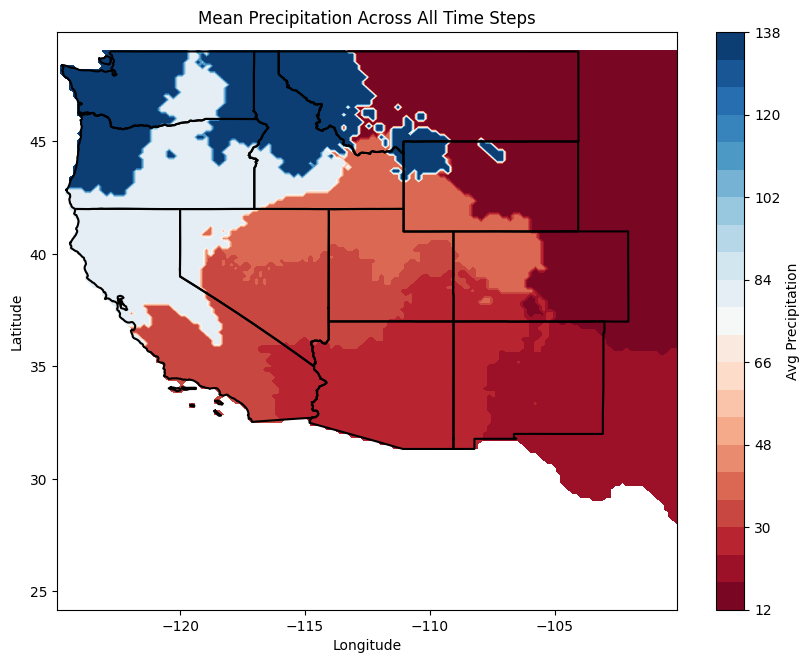

In [11]:
# Compute the mean precipitation per cluster over all time steps
mean_precip_per_pixel = np.mean(ppt_df['ppt_cluster'], axis=0)  # Shape (155, 150)

maskNans(mean_precip_per_pixel)

import numpy as np
import matplotlib.pyplot as plt

# Plot the mean precipitation per pixel
plt.figure(figsize=(10, 7.5))
xx, yy = np.meshgrid(lon, lat)
plt.contourf(xx, yy, mean_precip_per_pixel, levels=20, cmap="RdBu")  # Adjust levels for clarity
plt.colorbar(label="Avg Precipitation")
show_states()
plt.title("Mean Precipitation Across All Time Steps")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



### Now plot the mean precipitation across the months of interest

[24.328152   64.91203489 15.76888306 ... 35.01247683 26.39695971
 41.49447516]
0.006049178963276877 385.9723731884058
cluster averages for month 1: [ 13.59940609  27.54289097  11.3698327   13.60074389 157.86777257
   9.96304222  40.4710787   39.88999114 103.71104986]
cluster averages for month 2: [ 11.78955841  26.40546356  12.17911527  14.94106078 124.4518581
  12.8963982   37.10655022  39.01060224  86.62596039]
cluster averages for month 3: [ 18.55165571  26.2441016   21.89048598  17.3130612  119.10786535
  25.19406306  40.33132823  37.22912064  77.08163637]
cluster averages for month 10: [23.06081561 24.76733944 27.2239594  37.74206599 94.24387426 28.55073242
 32.93331141 19.05820694 39.88950762]
cluster averages for month 11: [ 14.9689405   20.9184689   14.35668181  17.93390732 156.76082775
  15.66684657  34.43895688  22.05327397  76.32927602]
cluster averages for month 12: [ 13.36430617  27.49190927  11.95903477  16.44527103 164.75890649
  12.81485901  37.84825996  31.9289845   99

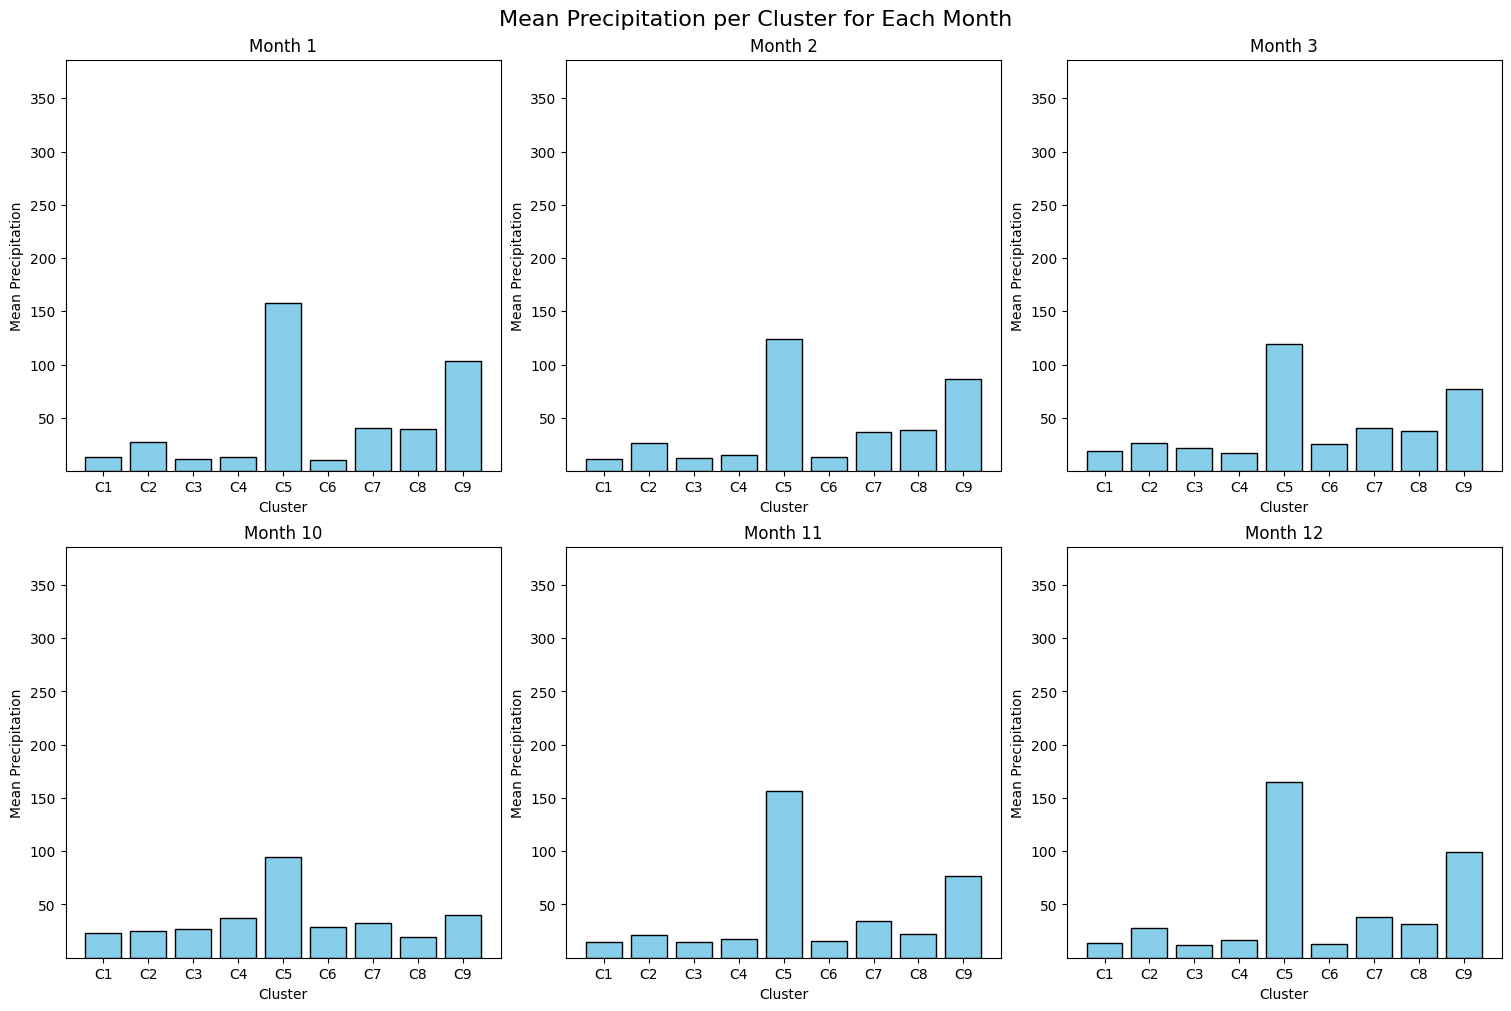

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define months of interest
months_of_interest = [1, 2, 3, 10, 11, 12]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
axes = axes.ravel()

# Compute mean precipitation for each month
mean_ppt_per_month = ppt_df.groupby('M')['ppt_cluster_vector'].apply(
    lambda x: np.nanmean(np.vstack(x), axis=0)
)


# Set up the colormap and normalization for visualization
ppt_data_list_flat = np.concatenate([arr.flatten() for arr in ppt_df['ppt_cluster_vector']])
print(ppt_data_list_flat)
global_min = np.nanmin(ppt_data_list_flat)
global_max = np.nanmax(ppt_data_list_flat) + 2

print(global_min, global_max)


# Loop through each month and plot its mean precipitation
for i, target_month in enumerate(months_of_interest):
    average_ppt_per_cluster = mean_ppt_per_month.loc[target_month]  # Shape of average_ppt_per_cluster is (9,)

    # Bar plot setup
    ax = axes[i]
    ax.set_title(f"Month {target_month}")
    x = np.arange(len(average_ppt_per_cluster))  # X locations for clusters (0-8)

    ax.bar(x, average_ppt_per_cluster, color='skyblue', edgecolor='black')

    # Formatting
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Mean Precipitation")
    ax.set_xticks(x)
    ax.set_xticklabels([f"C{c+1}" for c in x])  # Label clusters as C1, C2, ...
    
    # Apply global y-axis limits
    ax.set_ylim(global_min, global_max)


    print(f'cluster averages for month {target_month}: {average_ppt_per_cluster}')
    

plt.suptitle("Mean Precipitation per Cluster for Each Month", fontsize=16)
plt.show()


map shape: (155, 150)
number of datapoints for month 1: 127
number of datapoints for month 2: 127
number of datapoints for month 3: 127
number of datapoints for month 10: 126
number of datapoints for month 11: 126
number of datapoints for month 12: 126


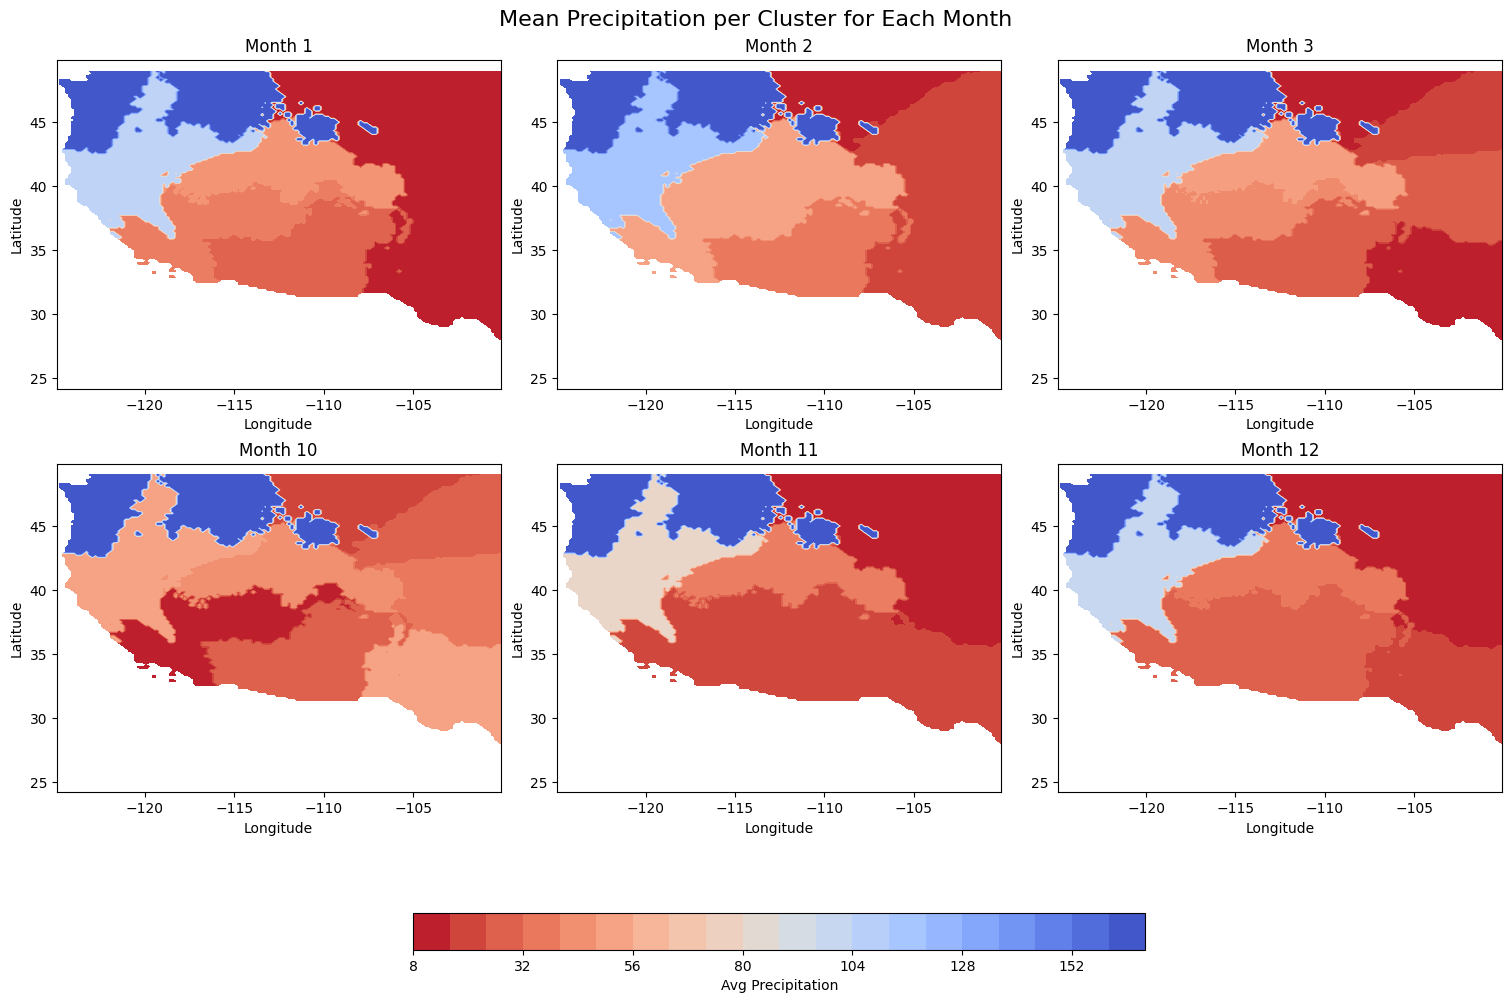

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Define months of interest (already in ppt_df)
months_of_interest = [1, 2, 3, 10, 11, 12]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
axes = axes.ravel()

# Loop through each month and plot its mean precipitation map
for i, target_month in enumerate(months_of_interest):
    
    # Extract all precipitation arrays for the given month and stack them
    month_data = np.stack(ppt_df[ppt_df['M'] == target_month]['ppt_cluster'].values)  # Shape (num samples with target_month, 155, 150)

    # Compute mean precipitation per pixel, handling NaNs and averaging over the time dimension
    mean_precip_per_pixel = np.nanmean(month_data, axis=0)  # Now correctly averaging over the time dimension

    maskNans(mean_precip_per_pixel)

    # Create meshgrid for plotting
    xx, yy = np.meshgrid(lon, lat)

    # Plot
    ax = axes[i]
    im = ax.contourf(xx, yy, mean_precip_per_pixel, levels=20, cmap="coolwarm_r")  # Adjust levels for clarity
    # show_states(ax)  # Function to overlay state boundaries
    ax.set_title(f"Month {target_month}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    if (i==0):
        print(f'map shape: {mean_precip_per_pixel.shape}')
    print(f'number of datapoints for month {target_month}: {month_data.shape[0]}')
    

# Add colorbar
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label("Avg Precipitation")

plt.suptitle("Mean Precipitation per Cluster for Each Month", fontsize=16)
plt.show()


## Now we want to visualize the absolute precipitation for each month, for each cluster. 

This should be the total rainfall in each cluster. We calculate this by taking every precipitation measurement in each cluster and summing it together. This finds the aggregate precipitation for each region.

First we will start by calculating the absolute precipitation for each cluster. `ppt_df` contains columns that show the mean precipitation. We calculate the sum of the precipitation measurements in the same way, and create a new dataframe to store these values.

In [14]:
from climate_dataset import aggregate_clusters

ppt_df_absolute = ppt_df.copy()
ppt_df_absolute["ppt_cluster_absolute"] = ppt_df["ppt"].apply(lambda x: aggregate_clusters(x, clusters))
ppt_df_absolute["ppt_cluster_absolute_vector"] = ppt_df["ppt"].apply(
    lambda x: aggregate_clusters(x, clusters, return_image=False)[:-1]
)

ppt_df_absolute.drop('ppt_cluster', axis=1, inplace=True)
ppt_df_absolute.drop('ppt_cluster_vector', axis=1, inplace=True)
ppt_df_absolute.head()

,F,Y,M,ppt,T,season,ppt_cluster_absolute,ppt_cluster_absolute_vector
0,ppt_1895_01.nc,1895,1,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[31675.254, 122553.92, 21619.139, 28736.686, 3..."
1,ppt_1895_02.nc,1895,2,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",2,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[22144.348, 44823.56, 21510.193, 45603.242, 10..."
2,ppt_1895_03.nc,1895,3,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",3,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[14070.834, 20227.707, 20756.465, 2417.2322, 1..."
3,ppt_1895_10.nc,1895,10,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[10434.447, 43506.35, 8711.675, 67656.984, 162..."
4,ppt_1895_11.nc,1895,11,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",11,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[29377.078, 88879.72, 29676.45, 46312.473, 190..."


Now we will plot the accumulated precipitation for each function and plot it on the map. We will save each of these as a GIF.

In [15]:
# UNCOMMENT TO GENEREATE PLOT
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize

# # Assuming 'cluster_ppt_avg' is the DataFrame column that contains the average precipitation data per cluster
# # cluster_ppt_avg shape: (700, 155, 150) -- (700 months, 155 longitudes, 150 latitudes)
# # 'clusters' shape: (155, 150) -- Cluster map
# # Create a figure and axis
# fig, ax = plt.subplots(figsize=(12, 8))

# abs_ppt_data_list = ppt_df_absolute['ppt_cluster_absolute']

# # Set up the colormap and normalization for visualization
# abs_ppt_data_list_flat = np.concatenate([arr.flatten() for arr in ppt_df_absolute['ppt_cluster_absolute']])

# # Compute min and max values while ignoring NaNs
# vmin = np.nanmin(abs_ppt_data_list_flat)
# vmax = np.nanmax(abs_ppt_data_list_flat)

# # Normalize the data
# norm = Normalize(vmin=vmin, vmax=vmax)

# cmap = cm.viridis  # You can change this to any colormap you prefer

# # Initialize the plot elements
# cluster_plot = ax.imshow(np.zeros_like(clusters), cmap=cmap, interpolation="none", norm=norm)
# cbar = fig.colorbar(cluster_plot, ax=ax)
# cbar.set_label('Precipitation (mm)', rotation=270, labelpad=20)

# # Set plot titles and labels
# ax.set_title("Cluster Precipitation over Time")
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')

# # Update function to update the plot for each frame
# def update(frame):
#     ax.clear()  # Clear the current axes
#     # Set up the cluster data for this frame
#     cluster_data = ppt_df_absolute['ppt_cluster_absolute'][frame]  # Access the data for the current frame (month)
    
#     maskNans(cluster_data)
#     # Plot the clusters for this month
#     cluster_plot = ax.imshow(cluster_data, cmap=cmap, interpolation="none", norm=norm)
    
#     # Add a title for the current month
#     ax.set_title(f"Aggregate Cluster Precipitation for Month {ppt_df_absolute['M'][frame]} Year {ppt_df_absolute['Y'][frame]}")
#     ax.set_xlabel('Longitude')
#     ax.set_ylabel('Latitude')
    
#     # Add the colorbar to the plot
    
#     cbar.set_label('Precipitation', rotation=270, labelpad=20)
    
#     # Optionally, you can plot the boundaries of the clusters on top of the precipitation
#     # ax.contour(clusters, levels=range(1, 10), colors='black', linewidths=1)  # Adjust the levels and colors as needed
    
#     return cluster_plot,

# # Create the animation
# ani = FuncAnimation(fig, update, frames=700, interval=100, blit=False)

# # Save the animation as a GIF
# ani.save('precipitation_clusters_absolute1.gif', writer='pillow', fps=10)


<img src="/Users/hayleywalters/Desktop/research 2025/ML_rain_prediction/precipitation_clusters_absolute1.gif"/>

This is a gif showing the aggregate precipitation for each cluster over the months of interest.

In [16]:
# UNCOMMENT TO GENEREATE PLOT
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize

# # Assuming 'ppt_df_absolute' contains the precipitation data and has columns 'ppt_cluster_absolute', 'M', and 'Y'
# # 'ppt_df_absolute['ppt_cluster_absolute']' is a list of arrays with precipitation data for each month
# # 'clusters' shape is (155, 150) for longitude and latitude

# # Create the figure with subplots for each of the six months
# fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
# axes = axes.ravel()

# # Set up the colormap and normalization for visualization
# abs_ppt_data_list_flat = np.concatenate([arr.flatten() for arr in ppt_df_absolute['ppt_cluster_absolute'].values])

# # Compute min and max values while ignoring NaNs
# vmin = np.nanmin(abs_ppt_data_list_flat)
# vmax = np.nanmax(abs_ppt_data_list_flat)

# # Normalize the data
# norm = Normalize(vmin=vmin, vmax=vmax)

# cmap = cm.viridis  # You can change this to any colormap you prefer

# # Define the months of interest
# months_of_interest = [1, 2, 3, 10, 11, 12]

# # Filter data for each month
# month_data = {}
# for month in months_of_interest:
#     month_data[month] = np.stack(ppt_df_absolute[ppt_df_absolute['M'] == month]['ppt_cluster_absolute'].values)

# # Create the subplots for the initial frame (showing all months)
# cluster_plots = []
# for i in range(6):
#     cluster_plots.append(axes[i].imshow(np.zeros_like(clusters), cmap=cmap, interpolation="none", norm=norm))

# # Add colorbar for the plots
# cbar = fig.colorbar(cluster_plots[0], ax=axes, orientation="horizontal", fraction=0.02, pad=0.04)
# cbar.set_label('Aggregate Precipitation', labelpad=20)

# # Set titles and labels for each subplot
# for ax in axes:
#     ax.set_xlabel('Longitude')
#     ax.set_ylabel('Latitude')

# # Update function to update the plot for each frame
# def update(frame):
#     # Clear previous subplots
#     for ax in axes:
#         ax.clear()

#     # Get data for each month and update the corresponding subplot
#     for i, month in enumerate(months_of_interest):
#         data = month_data[month][frame]  # Get the data for this frame (year) of the given month
#         axes[i].imshow(data, cmap=cmap, interpolation="none", norm=norm)
#         axes[i].set_title(f"Month {month} - Year {1895+frame}")

#     return cluster_plots

# # Create the animation
# iteration_limit = min(len(month_data[month]) for month in months_of_interest)
# ani = FuncAnimation(fig, update, frames=iteration_limit, interval=100, blit=False)

# # Save the animation as a GIF
# ani.save('precipitation_clusters_absolute_months.gif', writer='pillow', fps=8)

# # Optionally, display the plot during the animation
# # plt.show()


This GIF shows all the Aggregate rainfall for each cluster until 2020.

<img src="/Users/hayleywalters/Desktop/research 2025/ML_rain_prediction/precipitation_clusters_absolute_months.gif" />

Below is the same graph to predict the mean precipitation in the same way.

In [17]:
# UNCOMMENT TO GENEREATE PLOT
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize

# # Assuming 'ppt_df_absolute' contains the precipitation data and has columns 'ppt_cluster_absolute', 'M', and 'Y'
# # 'ppt_df_absolute['ppt_cluster_absolute']' is a list of arrays with precipitation data for each month
# # 'clusters' shape is (155, 150) for longitude and latitude

# # Create the figure with subplots for each of the six months
# fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
# axes = axes.ravel()

# # Set up the colormap and normalization for visualization
# abs_ppt_data_list_flat = np.concatenate([arr.flatten() for arr in ppt_df['ppt_cluster'].values])

# # Compute min and max values while ignoring NaNs
# vmin = np.nanmin(abs_ppt_data_list_flat)
# vmax = np.nanmax(abs_ppt_data_list_flat)

# # Normalize the data
# norm = Normalize(vmin=vmin, vmax=vmax)

# cmap = cm.viridis  # You can change this to any colormap you prefer

# # Define the months of interest
# months_of_interest = [1, 2, 3, 10, 11, 12]

# # Filter data for each month
# month_data = {}
# for month in months_of_interest:
#     month_data[month] = np.stack(ppt_df[ppt_df['M'] == month]['ppt_cluster'].values)

# # Create the subplots for the initial frame (showing all months)
# cluster_plots = []
# for i in range(6):
#     cluster_plots.append(axes[i].imshow(np.zeros_like(clusters), cmap=cmap, interpolation="none", norm=norm))

# # Add colorbar for the plots
# cbar = fig.colorbar(cluster_plots[0], ax=axes, orientation="horizontal", fraction=0.02, pad=0.04)
# cbar.set_label('Mean Precipitation', labelpad=20)

# # Set titles and labels for each subplot
# for ax in axes:
#     ax.set_xlabel('Longitude')
#     ax.set_ylabel('Latitude')

# # Update function to update the plot for each frame
# def update(frame):
#     # Clear previous subplots
#     for ax in axes:
#         ax.clear()

#     # Get data for each month and update the corresponding subplot
#     for i, month in enumerate(months_of_interest):
#         data = month_data[month][frame]  # Get the data for this frame (year) of the given month
#         axes[i].imshow(data, cmap=cmap, interpolation="none", norm=norm)
#         axes[i].set_title(f"Month {month} - Year {1895+frame}")

#     return cluster_plots

# # Create the animation
# iteration_limit = min(len(month_data[month]) for month in months_of_interest)
# ani = FuncAnimation(fig, update, frames=iteration_limit, interval=100, blit=False)

# # Save the animation as a GIF
# ani.save('precipitation_clusters_mean_months.gif', writer='pillow', fps=8)

# # Optionally, display the plot during the animation
# # plt.show()


<img src="precipitation_clusters_mean_months.gif"/>

In [18]:
# UNCOMMENT TO GENEREATE PLOT
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize

# # Assuming 'ppt_df_absolute' contains the precipitation data and has columns 'ppt_cluster_absolute', 'M', and 'Y'
# # 'ppt_df_absolute['ppt_cluster_absolute']' is a list of arrays with precipitation data for each month
# # 'clusters' shape is (155, 150) for longitude and latitude

# # Create the figure with subplots for each of the six months
# fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
# axes = axes.ravel()

# # Set up the colormap and normalization for visualization
# abs_ppt_data_list_flat = np.concatenate([arr.flatten() for arr in ppt_df_absolute['ppt_cluster_absolute'].values])

# # Compute min and max values while ignoring NaNs
# vmin = np.nanmin(abs_ppt_data_list_flat)
# vmax = np.nanmax(abs_ppt_data_list_flat)

# # Normalize the data
# norm = Normalize(vmin=vmin, vmax=vmax)

# cmap = cm.viridis  # You can change this to any colormap you prefer

# # Define the months of interest
# months_of_interest = [1, 2, 3, 10, 11, 12]

# # Filter data for each month
# month_data = {}
# for month in months_of_interest:
#     month_data[month] = np.stack(ppt_df_absolute[ppt_df_absolute['M'] == month]['ppt_cluster_absolute'].values)

# # Create the subplots for the initial frame (showing all months)
# cluster_plots = []
# for i in range(6):
#     cluster_plots.append(axes[i].imshow(np.zeros_like(clusters), cmap=cmap, interpolation="none", norm=norm))

# # Add colorbar for the plots
# cbar = fig.colorbar(cluster_plots[0], ax=axes, orientation="horizontal", fraction=0.02, pad=0.04)
# cbar.set_label('Aggregate Precipitation', labelpad=20)

# # Set titles and labels for each subplot
# for ax in axes:
#     ax.set_xlabel('Longitude')
#     ax.set_ylabel('Latitude')

# # Update function to update the plot for each frame
# def update(frame):
#     # Clear previous subplots
#     for ax in axes:
#         ax.clear()

#     # Get data for each month and update the corresponding subplot
#     for i, month in enumerate(months_of_interest):
#         data = month_data[month][frame]  # Get the data for this frame (year) of the given month
#         maskNans(data)
#         axes[i].imshow(data, cmap=cmap, interpolation="none", norm=norm)
#         axes[i].set_title(f"Month {month} - Year {1895+frame}")

#     return cluster_plots

# # Create the animation
# iteration_limit = min(len(month_data[month]) for month in months_of_interest)
# ani = FuncAnimation(fig, update, frames=iteration_limit, interval=100, blit=False)

# # Save the animation as a GIF
# ani.save('precipitation_clusters_absolute_months1.gif', writer='pillow', fps=8)


<img src="precipitation_clusters_absolute_months.gif"/>

Now I will use the same plot and try to plot the raw precipitation for comparison.

In [19]:
# UNCOMMENT TO GENEREATE PLOT
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize

# # Assuming 'ppt_df_absolute' contains the precipitation data and has columns 'ppt_cluster_absolute', 'M', and 'Y'
# # 'ppt_df_absolute['ppt_cluster_absolute']' is a list of arrays with precipitation data for each month
# # 'clusters' shape is (155, 150) for longitude and latitude

# # Create the figure with subplots for each of the six months
# fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
# axes = axes.ravel()

# # Set up the colormap and normalization for visualization
# abs_ppt_data_list_flat = np.concatenate([arr.flatten() for arr in ppt_df_absolute['ppt'].values])

# # Compute min and max values while ignoring NaNs
# vmin = np.nanmin(abs_ppt_data_list_flat)
# vmax = np.nanmax(abs_ppt_data_list_flat)

# # Normalize the data
# norm = Normalize(vmin=vmin, vmax=vmax)

# cmap = cm.viridis  # You can change this to any colormap you prefer

# # Define the months of interest
# months_of_interest = [1, 2, 3, 10, 11, 12]

# # Filter data for each month
# month_data = {}
# for month in months_of_interest:
#     month_data[month] = np.stack(ppt_df_absolute[ppt_df_absolute['M'] == month]['ppt'].values)

# # Create the subplots for the initial frame (showing all months)
# cluster_plots = []
# for i in range(6):
#     cluster_plots.append(axes[i].imshow(np.zeros_like(clusters), cmap=cmap, interpolation="none", norm=norm))

# # Add colorbar for the plots
# cbar = fig.colorbar(cluster_plots[0], ax=axes, orientation="horizontal", fraction=0.02, pad=0.04)
# cbar.set_label('Aggregate Precipitation', labelpad=20)

# # Set titles and labels for each subplot
# for ax in axes:
#     ax.set_xlabel('Longitude')
#     ax.set_ylabel('Latitude')

# # Update function to update the plot for each frame
# def update(frame):
#     # Clear previous subplots
#     for ax in axes:
#         ax.clear()

#     # Get data for each month and update the corresponding subplot
#     for i, month in enumerate(months_of_interest):
#         data = month_data[month][frame]  # Get the data for this frame (year) of the given month
#         axes[i].imshow(data, cmap=cmap, interpolation="none", norm=norm)
#         axes[i].set_title(f"Month {month} - Year {1895+frame}")
#         axes[i].contour(clusters, levels=range(0, 8), colors='black', linewidths=1)  # Adjust the levels and colors as needed

#     return cluster_plots

# # Create the animation
# iteration_limit = min(len(month_data[month]) for month in months_of_interest)
# ani = FuncAnimation(fig, update, frames=10, interval=100, blit=False)

# # Save the animation as a GIF
# ani.save('precipitation_ppt_raw_months.gif', writer='pillow', fps=8)


<image src="precipitation_ppt_raw_months.gif" />

In [20]:
# UNCOMMENT TO GENERATE PLOT.
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize

# # Create three subplots with increased figure size
# fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
# axes = axes.ravel()  # Flatten axes array

# # Extract precipitation data
# abs_ppt_data_list = ppt_df_absolute['ppt_cluster_absolute']
# ppt_data_list = ppt_df_absolute['ppt']
# mean_ppt_data_list = ppt_df['ppt_cluster']

# # Compute global min/max for normalization
# abs_ppt_data_list_flat = np.concatenate([arr.flatten() for arr in abs_ppt_data_list])
# ppt_data_list_flat = np.concatenate([arr.flatten() for arr in ppt_data_list])
# mean_ppt_data_list_flat = np.concatenate([arr.flatten() for arr in mean_ppt_data_list])

# vmin_abs, vmax_abs = np.nanmin(abs_ppt_data_list_flat), np.nanmax(abs_ppt_data_list_flat)
# vmin_ppt, vmax_ppt = np.nanmin(ppt_data_list_flat), np.nanmax(ppt_data_list_flat)
# vmin_mean, vmax_mean = np.nanmin(mean_ppt_data_list_flat), np.nanmax(mean_ppt_data_list_flat)

# # Normalize
# norm_abs = Normalize(vmin=vmin_abs, vmax=vmax_abs)
# norm_ppt = Normalize(vmin=vmin_ppt, vmax=vmax_ppt)
# norm_mean = Normalize(vmin=vmin_mean, vmax=vmax_mean)
# cmap = cm.viridis  # Colormap

# # Initialize the first plot
# cluster_plot_abs = axes[0].imshow(np.full_like(clusters, np.nan, dtype=float), cmap=cmap, interpolation="none", norm=norm_abs)
# cbar1 = fig.colorbar(cluster_plot_abs, ax=axes[0])
# cbar1.set_label('Precipitation', rotation=270, labelpad=20)
# axes[0].set_title("Aggregate Cluster Precipitation")
# axes[0].set_xlabel('Longitude')
# axes[0].set_ylabel('Latitude')

# # Initialize the second plot
# cluster_plot = axes[1].imshow(np.full_like(clusters, np.nan, dtype=float), cmap=cmap, interpolation="none", norm=norm_ppt)
# cbar2 = fig.colorbar(cluster_plot, ax=axes[1])
# cbar2.set_label('Precipitation', rotation=270, labelpad=20)
# axes[1].set_title("Total Cluster Precipitation")
# axes[1].set_xlabel('Longitude')
# axes[1].set_ylabel('Latitude')

# # Initialize the third plot
# cluster_plot_mean = axes[2].imshow(np.full_like(clusters, np.nan, dtype=float), cmap=cmap, interpolation="none", norm=norm_mean)
# cbar3 = fig.colorbar(cluster_plot_mean, ax=axes[2])
# cbar3.set_label('Precipitation', rotation=270, labelpad=20)
# axes[2].set_title("Mean Cluster Precipitation")
# axes[2].set_xlabel('Longitude')
# axes[2].set_ylabel('Latitude')

# # Update function for animation
# def update(frame):
#     cluster_data_abs = abs_ppt_data_list[frame]  # Get frame data for first plot
#     cluster_data = ppt_data_list[frame]  # Get frame data for second plot
#     cluster_data_mean = mean_ppt_data_list[frame]  # Get frame data for third plot

#     cluster_plot_abs.set_data(cluster_data_abs)
#     cluster_plot.set_data(cluster_data)
#     cluster_plot_mean.set_data(cluster_data_mean)

#     axes[0].set_title(f"Aggregate Precipitation per Cluster\nMonth {ppt_df_absolute['M'][frame]} Year {ppt_df_absolute['Y'][frame]}")
#     axes[1].set_title(f"Unclustered Precipitation\nMonth {ppt_df_absolute['M'][frame]} Year {ppt_df_absolute['Y'][frame]}")
#     axes[2].set_title(f"Mean Precipitation\nMonth {ppt_df_absolute['M'][frame]} Year {ppt_df_absolute['Y'][frame]}")

#     for ax in axes:
#         ax.contour(clusters, levels=range(0, 8), colors='black', linewidths=1)  # Cluster boundaries

#     return cluster_plot_abs, cluster_plot, cluster_plot_mean

# # Create animation
# ani = FuncAnimation(fig, update, frames=len(ppt_df_absolute['M']), interval=100, blit=False)

# # Save as GIF
# ani.save('precipitation_clusters_absolute_unclustered_mean.gif', writer='pillow', fps=10)


<image src="generated_figures/precipitation_clusters_absolute_unclustered_mean.gif" />

## Visualizing how much clusters are deviating from their norm

subtract the cluster mean from cluster ppt, divide by cluster stdev

- lets you plot whether ppt is above or below the mean (red for below, blue for above)

visualize stdev for all clusters


To do this, I will do the same things I did to generate the plots for standard deviation. 

This time I will be plotting the standard deviation for the clusters.

In [31]:
from climate_dataset import std_clusters

ppt_df["ppt_cluster_std"] = ppt_df["ppt"].apply(lambda x: std_clusters(x, clusters))
ppt_df["ppt_cluster_std_vector"] = ppt_df["ppt"].apply(
    lambda x: std_clusters(x, clusters, return_image=False)[:-1]
)

ppt_df.tail()

,F,Y,M,ppt,T,season,ppt_cluster,ppt_cluster_vector,ppt_cluster_std,ppt_cluster_std_vector
754,ppt_2020_11.nc,2020,11,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1511,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[13.73604010656682, 10.052342301708157, 2.5142...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[9.390557289123535, 15.281928062438965, 2.7432..."
755,ppt_2020_12.nc,2020,12,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1512,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[5.1910664782546085, 10.991184040651483, 6.766...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[5.042848110198975, 12.759134292602539, 5.6754..."
756,ppt_2021_01.nc,2021,1,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1513,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[6.451732910906298, 27.87617311639301, 6.03239...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[6.242330074310303, 21.111675262451172, 4.2553..."
757,ppt_2021_02.nc,2021,2,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1514,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[16.593416978686637, 10.121352373543433, 11.21...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[13.083651542663574, 12.84913158416748, 8.7861..."
758,ppt_2021_03.nc,2021,3,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",1515,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[9.299887192780337, 17.95408501059322, 21.5436...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[8.6873779296875, 18.02971076965332, 22.596336..."


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define months of interest (already in ppt_df)
months_of_interest = [1, 2, 3, 10, 11, 12]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
axes = axes.ravel()

# Loop through each month and plot its mean precipitation map
for i, target_month in enumerate(months_of_interest):
    
    # Extract all precipitation arrays for the given month and stack them
    month_data = np.stack(ppt_df[ppt_df['M'] == target_month]['ppt_cluster_std'].values)  # Shape (num samples with target_month, 155, 150)

    # Compute mean precipitation per pixel, handling NaNs and averaging over the time dimension
    mean_precip_per_pixel = np.nanmean(month_data, axis=0)  # Now correctly averaging over the time dimension

    maskNans(mean_precip_per_pixel)

    # Create meshgrid for plotting
    xx, yy = np.meshgrid(lon, lat)

    # Plot
    ax = axes[i]
    im = ax.contourf(xx, yy, mean_precip_per_pixel, levels=20, cmap="coolwarm_r")  # Adjust levels for clarity
    # show_states(ax)  # Function to overlay state boundaries
    ax.set_title(f"Month {target_month}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    if (i==0):
        print(f'map shape: {mean_precip_per_pixel.shape}')
    print(f'number of datapoints for month {target_month}: {month_data.shape[0]}')
    

# Add colorbar
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label("Avg Precipitation")

plt.suptitle("Mean Precipitation per Cluster for Each Month", fontsize=16)
plt.show()


In [22]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA

# # Step 2: PCA for Year-over-Year Precipitation Changes
# # Apply PCA on the precipitation data per cluster for all months
# pca = PCA(n_components=2)  # Reduce to 2 components for easier visualization
# pca_result = pca.fit_transform(avg_clusters.reshape(avg_clusters.shape[0], -1))  # Flatten for PCA

# # Visualize the PCA results
# plt.figure(figsize=(10, 6))
# plt.scatter(pca_result[:, 0], pca_result[:, 1], c=filtered_data['Y'], cmap='viridis')
# plt.colorbar(label='Year')
# plt.xlabel('PCA Component 1')
# plt.ylabel('PCA Component 2')
# plt.title('PCA of Precipitation Changes Year-over-Year')
# plt.show()


In [23]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA

# # Define the months of interest
# months_of_interest = [1, 2, 3, 10, 11, 12]

# # Set up the figure
# fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns
# axes = axes.ravel()  # Flatten to easily index

# # Loop through each month and apply PCA
# for i, month in enumerate(months_of_interest):
#     # Filter data for the current month
#     month_mask = filtered_data['M'] == month
#     month_data = avg_clusters[month_mask]  # Select only the data for this month

#     # Apply PCA
#     pca = PCA(n_components=2)  
#     pca_result = pca.fit_transform(month_data.reshape(month_data.shape[0], -1))  # Flatten for PCA

#     # Scatter plot in the corresponding subplot
#     ax = axes[i]
#     scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], c=filtered_data['Y'][month_mask], cmap='viridis')
#     ax.set_title(f'PCA for Month {month}')
#     ax.set_xlabel('PCA Component 1')
#     ax.set_ylabel('PCA Component 2')

#     # Add colorbar
#     cbar = fig.colorbar(scatter, ax=ax)
#     cbar.set_label('Year')

# # Adjust layout
# plt.tight_layout()
# plt.show()


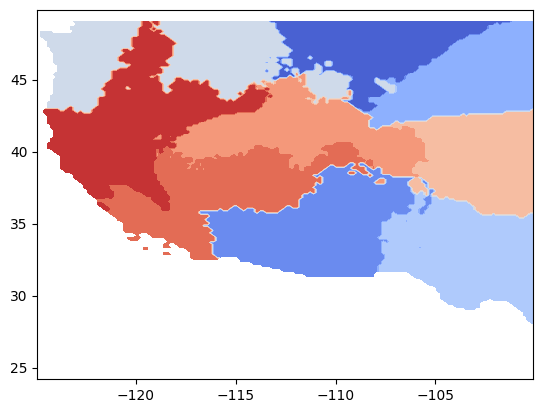

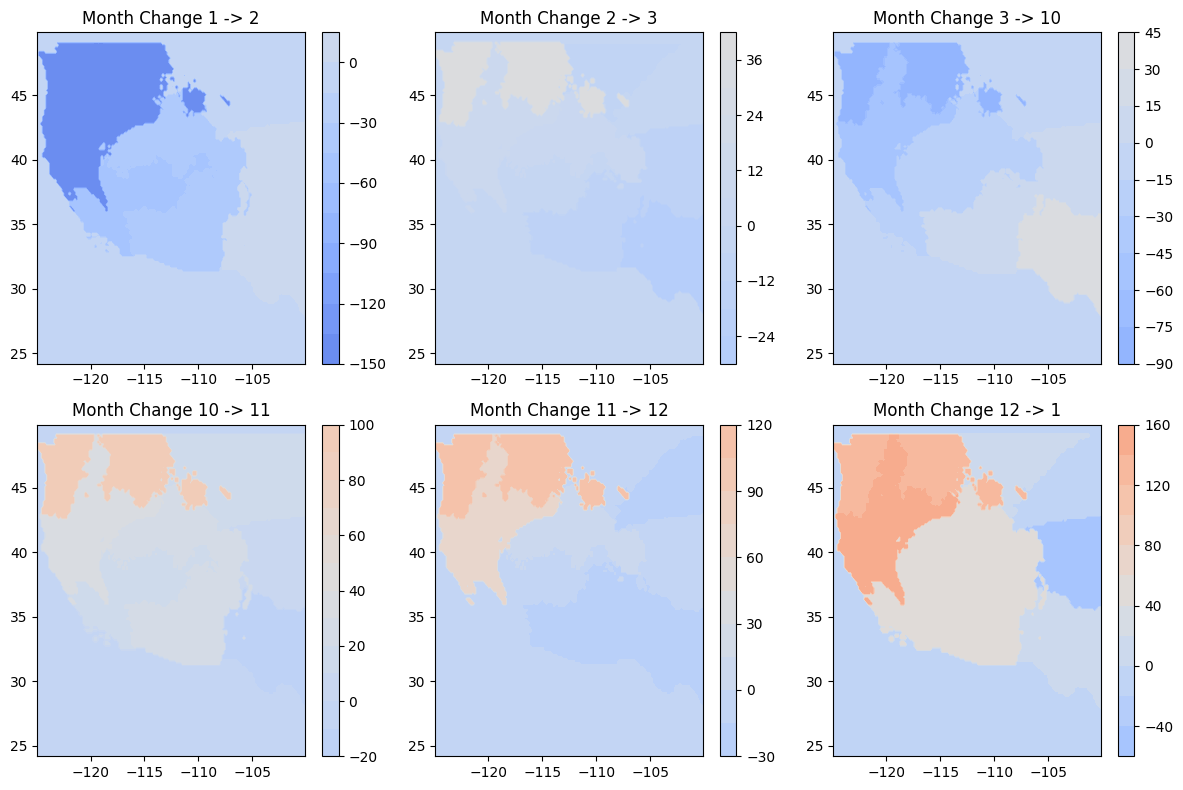

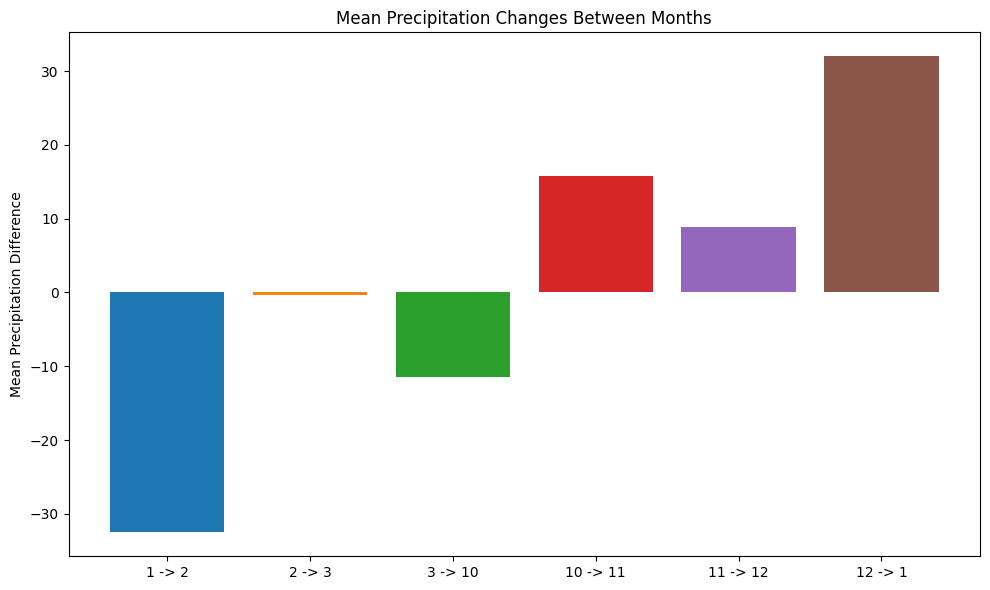

In [24]:
avg_clusters = ppt_df['ppt_cluster'].tolist()
# Plot the average precipitation difference between months
month_diff = np.diff(avg_clusters, axis=0)  # Difference between consecutive months


# Add the December (12) -> January (1) change
# Ensure that the dimensions match (reshape to match avg_clusters' shape)
dec_to_jan_diff = avg_clusters[0] - avg_clusters[-1]  # Calculate difference for month 12 -> 1

# Ensure dec_to_jan_diff has the same shape (3D) as avg_clusters
dec_to_jan_diff = np.expand_dims(dec_to_jan_diff, axis=0)  # Adding an extra dimension for time

# Append the December->January difference to the month_diff array
month_diff = np.concatenate([month_diff, dec_to_jan_diff], axis=0)

# Find the global min and max across all month-to-month differences
global_min = np.min(month_diff)
global_max = np.max(month_diff)

# plt.figure(figsize=(12, 8))

plt.contourf(xx, yy, clusters, levels=10, cmap="coolwarm")

# Now plotting the changes, including Dec->Jan
plt.figure(figsize=(12, 8))
for i, (current_month, next_month) in enumerate(zip(months_of_interest[:-1], months_of_interest[1:])):
    plt.subplot(2, 3, i + 1)
    xx, yy = np.meshgrid(lon, lat)
    # Use global_min and global_max for consistent color scaling
    c = plt.contourf(xx, yy, month_diff[i], levels=10, cmap="coolwarm", vmin=global_min, vmax=global_max)
    plt.colorbar(c)
    plt.title(f"Month Change {current_month} -> {next_month}")

# Add the December (12) -> January (1) plot
plt.subplot(2, 3, len(months_of_interest))  # Last subplot for Dec->Jan
c = plt.contourf(xx, yy, month_diff[-1], levels=10, cmap="coolwarm", vmin=global_min, vmax=global_max)
plt.colorbar(c)
plt.title("Month Change 12 -> 1")

plt.tight_layout()
plt.show()

# Summarize the changes with bar plots
plt.figure(figsize=(10, 6))
for i, (current_month, next_month) in enumerate(zip(months_of_interest[:-1], months_of_interest[1:])):
    # Calculate the mean difference across the latitude and longitude dimensions
    mean_diff = np.mean(month_diff[i], axis=(0, 1))  # Mean across latitude and longitude
    plt.bar(f"{current_month} -> {next_month}", mean_diff)

# Add the December (12) -> January (1) plot
mean_diff_dec_to_jan = np.mean(month_diff[-1], axis=(0, 1))
plt.bar("12 -> 1", mean_diff_dec_to_jan)

plt.ylabel("Mean Precipitation Difference")
plt.title("Mean Precipitation Changes Between Months")
plt.tight_layout()
plt.show()


normalize the data per region/cluster, so that the percent change from baseline ppt is more clear.

This is done by normalizing the precipitation data of each cluster. The differences in precipitation between each cluster is calculated by dividing the difference in precipitation by the average rain fall in that cluster. In this way, the differnces in precipitation are showed as a percentage of the average rainfall in that cluster.

In [25]:
# Compute the mean precipitation per cluster across relevant months
cluster_means = np.mean(avg_clusters, axis=0)  # Shape: (num_clusters,)

small_value = 1e-6
cluster_means[cluster_means == 0] = small_value

# Compute month-to-month differences
month_diff = np.diff(avg_clusters, axis=0)

# Compute Dec (12) -> Jan (1) difference
dec_to_jan_diff = avg_clusters[0] - avg_clusters[-1]
dec_to_jan_diff = np.expand_dims(dec_to_jan_diff, axis=0)

# Append Dec->Jan difference to month_diff
month_diff = np.concatenate([month_diff, dec_to_jan_diff], axis=0)

# Normalize by cluster mean precipitation (avoid division by zero)
normalized_diff = (month_diff / cluster_means) * 100  # Convert to percentage change

# Find global min and max for consistent color scaling
global_min = np.min(normalized_diff)
global_max = np.max(normalized_diff)

# Plot the normalized changes
plt.figure(figsize=(12, 8))
for i, (current_month, next_month) in enumerate(zip(relevant_months[:-1], relevant_months[1:])):
    plt.subplot(2, 3, i + 1)
    xx, yy = np.meshgrid(lon, lat)
    c = plt.contourf(xx, yy, normalized_diff[i], levels=10, cmap="coolwarm", vmin=global_min, vmax=global_max)
    plt.colorbar(c)
    plt.title(f"Month Change {current_month} -> {next_month} (% of cluster mean)")

# Add the December (12) -> January (1) plot
plt.subplot(2, 3, len(relevant_months))
c = plt.contourf(xx, yy, normalized_diff[-1], levels=10, cmap="coolwarm", vmin=global_min, vmax=global_max)
plt.colorbar(c)
plt.title("Month Change 12 -> 1 (% of cluster mean)")

plt.tight_layout()
plt.show()


NameError: name 'relevant_months' is not defined

<Figure size 1200x800 with 0 Axes>

# Average Rainfall For Each Month of Interest

Compute the mean precipitation per cluster across relevant months

In [ ]:
avg_clusters.shape

(759, 155, 150)

The shape should be (759, 155, 150) which is 759 

In [ ]:
print(avg_clusters[0].shape)

(155, 150)


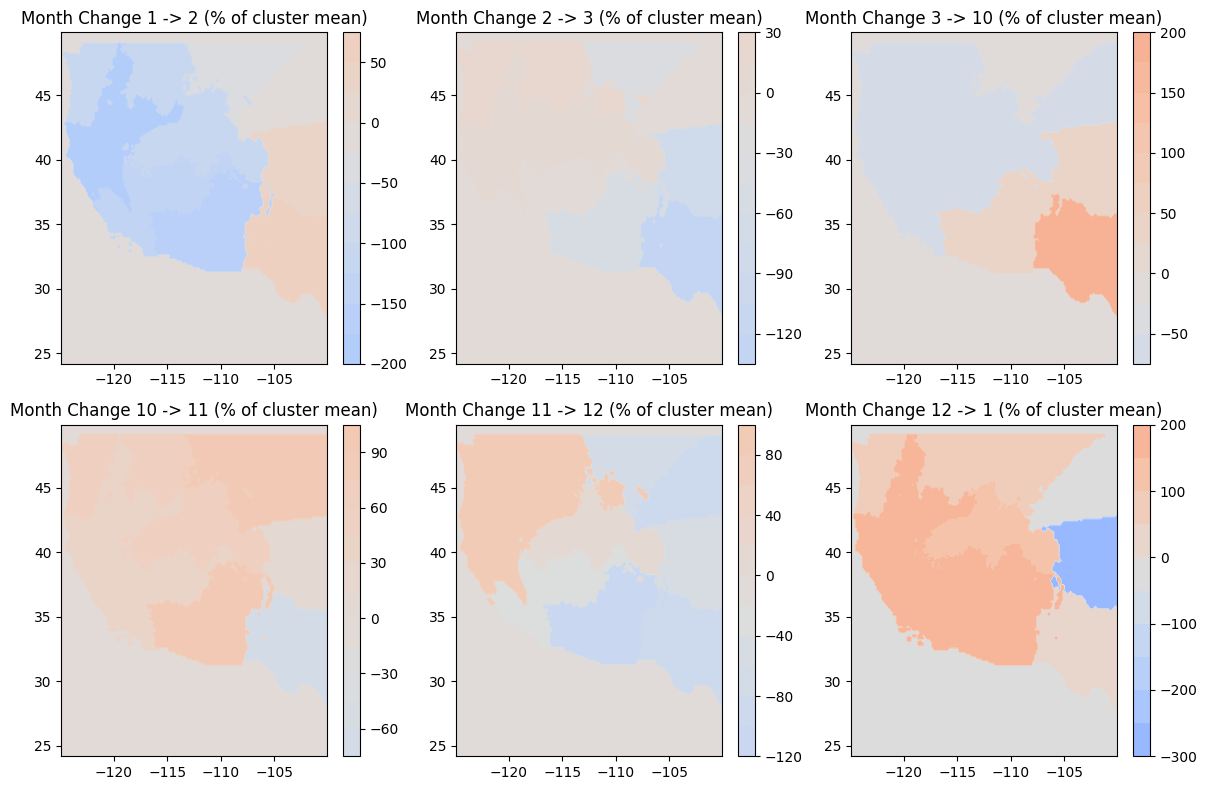

In [ ]:
# Compute the mean precipitation per cluster across relevant months


small_value = 1e-6
cluster_means[cluster_means == 0] = small_value

# Compute month-to-month differences
month_diff = np.diff(avg_clusters, axis=0)

# Compute Dec (12) -> Jan (1) difference
dec_to_jan_diff = avg_clusters[0] - avg_clusters[-1]
dec_to_jan_diff = np.expand_dims(dec_to_jan_diff, axis=0)

# Append Dec->Jan difference to month_diff
month_diff = np.concatenate([month_diff, dec_to_jan_diff], axis=0)

# Normalize by cluster mean precipitation (avoid division by zero)
normalized_diff = (month_diff / cluster_means) * 100  # Convert to percentage change

# Find global min and max for consistent color scaling
global_min = np.min(normalized_diff)
global_max = np.max(normalized_diff)

# Plot the normalized changes
plt.figure(figsize=(12, 8))
for i, (current_month, next_month) in enumerate(zip(relevant_months[:-1], relevant_months[1:])):
    plt.subplot(2, 3, i + 1)
    xx, yy = np.meshgrid(lon, lat)
    c = plt.contourf(xx, yy, normalized_diff[i], levels=10, cmap="coolwarm", vmin=global_min, vmax=global_max)
    plt.colorbar(c)
    plt.title(f"Month Change {current_month} -> {next_month} (% of cluster mean)")

# Add the December (12) -> January (1) plot
plt.subplot(2, 3, len(relevant_months))
c = plt.contourf(xx, yy, normalized_diff[-1], levels=10, cmap="coolwarm", vmin=global_min, vmax=global_max)
plt.colorbar(c)
plt.title("Month Change 12 -> 1 (% of cluster mean)")

plt.tight_layout()
plt.show()


plot avg rainfall month -> month

make visual for absolute ppt over time, (per cluster) 